In [523]:
# Combine Time-Dependence and SimpleDiff

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sympy import *
import matplotlib.pyplot as plt
import random as rand
init_printing(use_latex=true)
filename = "DataGeneric.xlsx"

In [580]:
# Establish symbols
n, T, k, i, j, t, lda, lda2 = symbols('n T k i j t \lambda \lambda_2')       
# n wells & T timepoints
# k = highest degree of w polynomial

In [581]:
# Choose highest degree of polynomial
k = 2

In [582]:
# Choose how often data is provided (p = number of training data points provided to the model)
pTrain = 10
pTest = 20

In [583]:
# Establish number of wells
n = len(pd.read_excel(filename, sheet_name="OnOff").to_numpy().T)
n

In [584]:
# Establish number of timepoints
T = len(pd.read_excel(filename, sheet_name="OnOff").to_numpy().T[0])
T

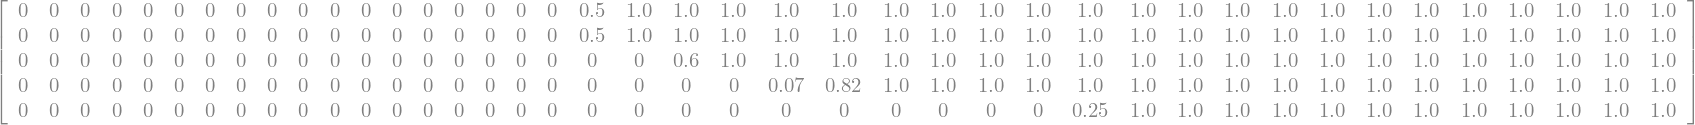

In [585]:
# Establish non-binary matrix for wells being on or off
# e.g. if well is on for 1/2 of the month, zij = 0.5
z = MatrixSymbol('z', n, T)      # Row 0 = well 0   , Column 3 = Timepoint 3
#pprint(z.as_explicit())
zReal = Matrix(pd.read_excel(filename, sheet_name="OnOff").to_numpy().T)
zReal

In [586]:
zTotal = int(sum(row for row in zReal if row == 1))
sampleTrain = rand.sample(range(zTotal), pTrain)
sampleTest = rand.sample([fruit for fruit in list(range(zTotal)) if fruit not in sampleTrain], pTest)
sampleTrain, sampleTest

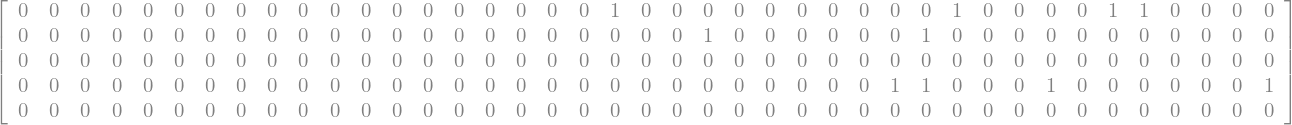

In [587]:
# Establish binary matrix for wells being measured or not
d = MatrixSymbol('d', n, T)      # Row 0 = well 0   , Column 3 = Timepoint 3
#pprint(d.as_explicit())
dTrain = Matrix(zeros(n, T))
index = 0
for i2 in range(n):
    for j2 in range(T):
        if zReal[i2,j2]==1.0:
            #print(i2, j2)
            if index in sample:
                dTrain[i2, j2] = 1
            index = index + 1
dTrain

In [588]:
dTotal = sum(dTrain)
dTotal

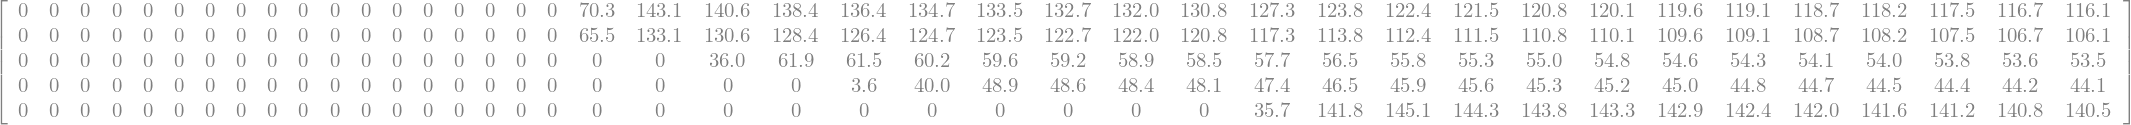

In [589]:
# Establish matrix of actual mass flows
m = MatrixSymbol('m', n, T)  
#pprint(m.as_explicit())
mReal = Matrix(pd.read_excel(filename, sheet_name="MassFlows").to_numpy().T)
mReal

In [590]:
# Establish matrix / vector of total mass flow
M = MatrixSymbol('M', 1, T)
#pprint(M.as_explicit())
MReal = Matrix(pd.read_excel(filename, sheet_name="TotalMassFlow").to_numpy().T)
MReal

In [591]:
# Set w as an expression based on t
wMat = MatrixSymbol('w', n, k+1)
pprint(wMat.as_explicit())

⎡w₀₀  w₀₁  w₀₂⎤
⎢             ⎥
⎢w₁₀  w₁₁  w₁₂⎥
⎢             ⎥
⎢w₂₀  w₂₁  w₂₂⎥
⎢             ⎥
⎢w₃₀  w₃₁  w₃₂⎥
⎢             ⎥
⎣w₄₀  w₄₁  w₄₂⎦


In [592]:
# Instantaneous value of wi is wMati * [1, t, t^2, t^3 etc]
tList = []
for power in range(k+1):
    tList.append(t**power)
ts = Matrix(tList)
wInstant = Matrix([wMat[i,:].as_explicit().dot(ts) for i in range(n)])
wInstant[0,0]

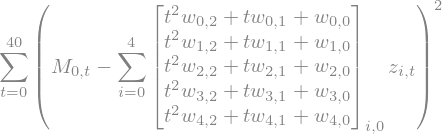

In [593]:
S1 = Sum((M[0,t] - Sum(z[i, t]*wInstant[i,0], (i, 0, n-1)))**2 , (t, 0, T-1))
S1

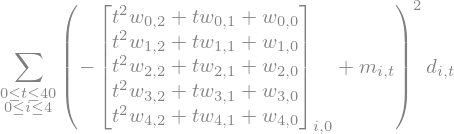

In [594]:
S2 = Sum(Sum(d[i,t]*((m[i,t]-wInstant[i,0]))**2 , (t, 0, T-1)), (i, 0, n-1))
S2

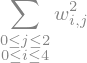

In [595]:
Ridge = Sum(Sum(wMat[i,j]**2 , (j, 0, k)), (i, 0, n-1))
Ridge

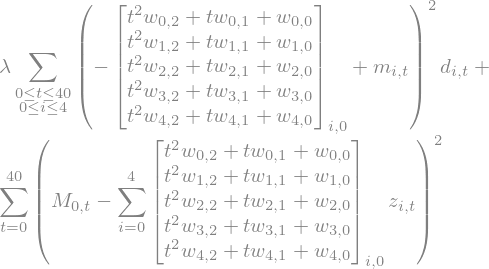

In [596]:
# ignore ridge for now
I = S1 + lda*S2 #+ lda2*Ridge
I

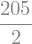

In [597]:
optLda = T*n**2/dTotal
optLda

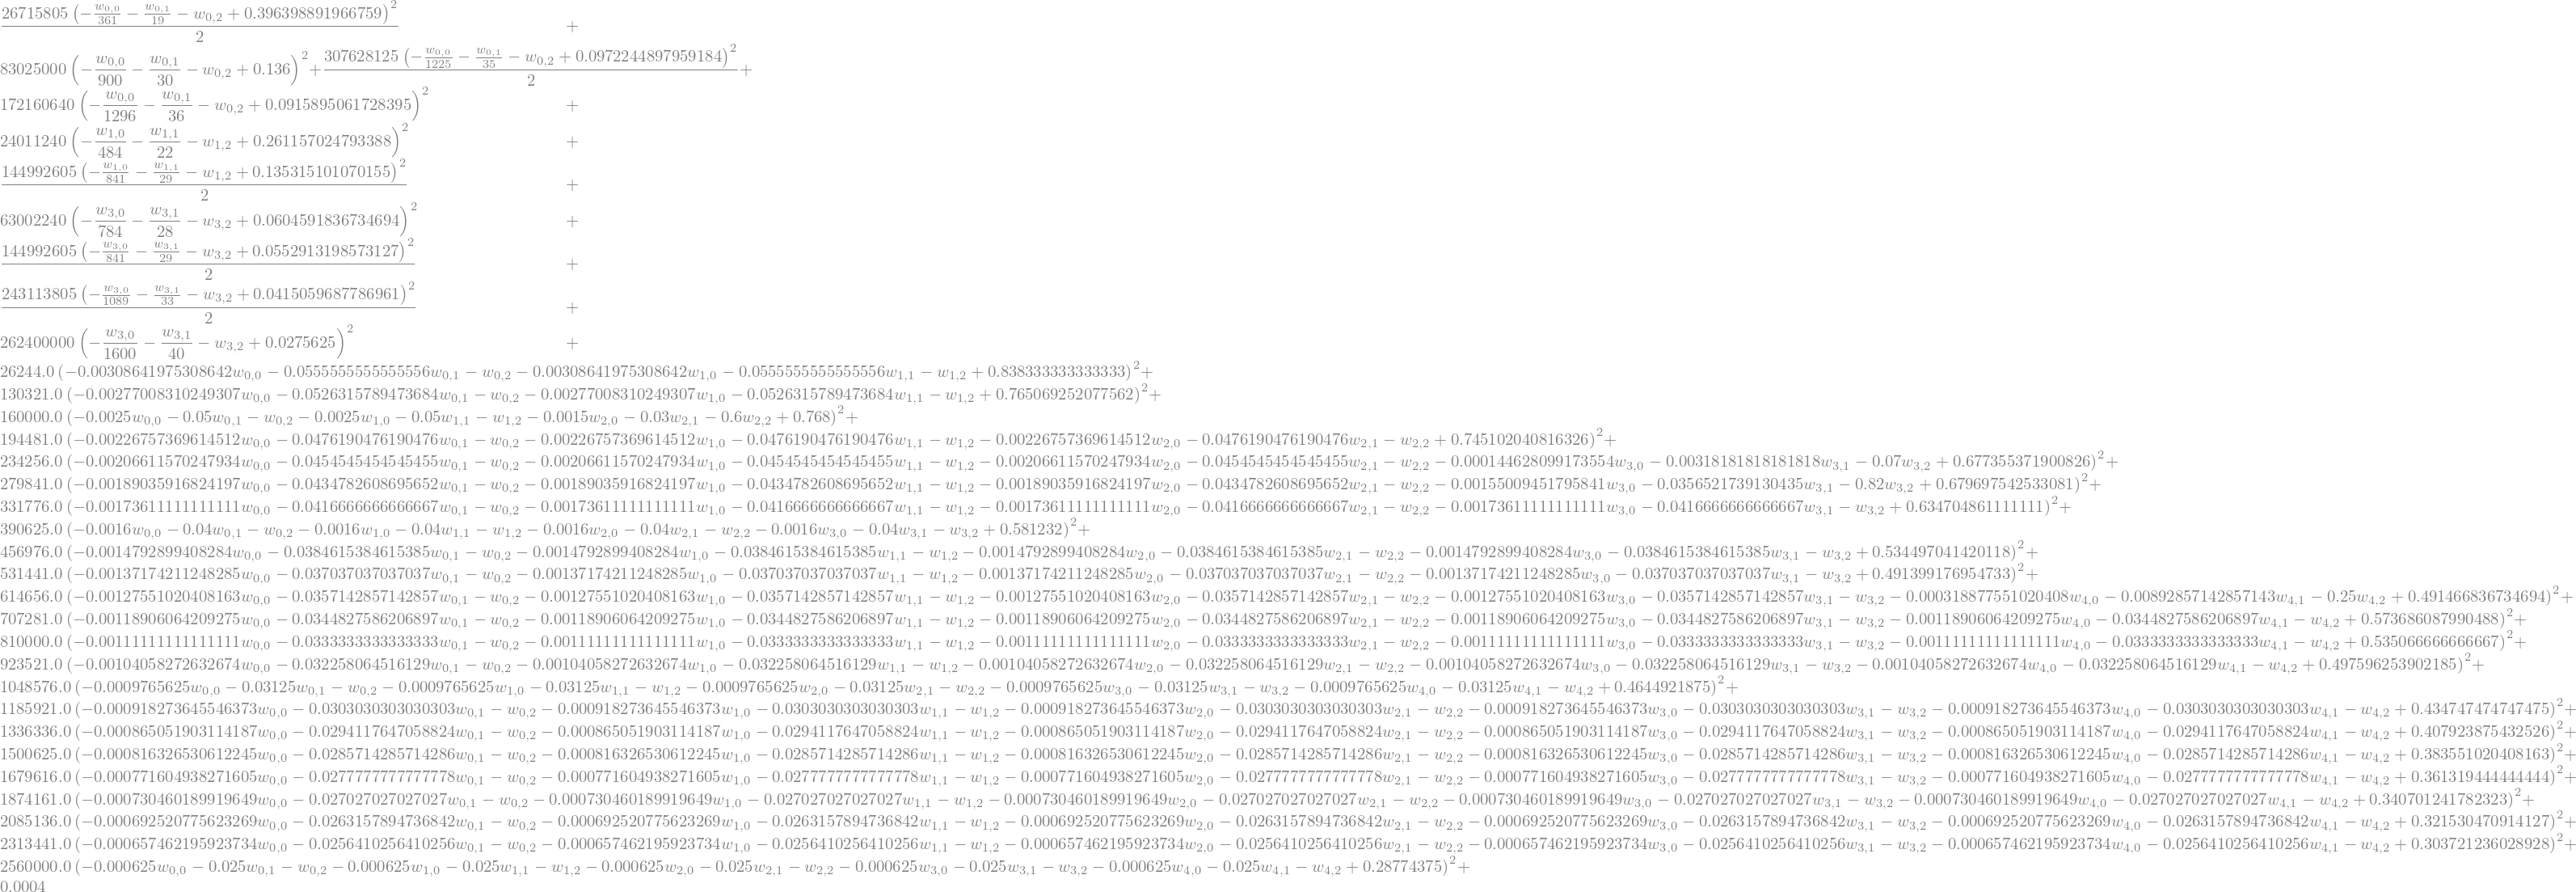

In [598]:
lda2value = 50
Inac = I.subs({M: MReal, z: zReal, d: dTrain, m: mReal, lda: optLda, lda2: lda2value}).doit()
Inac

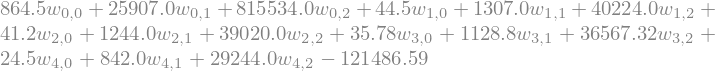

In [599]:
Inac.diff(wMat[0,0])

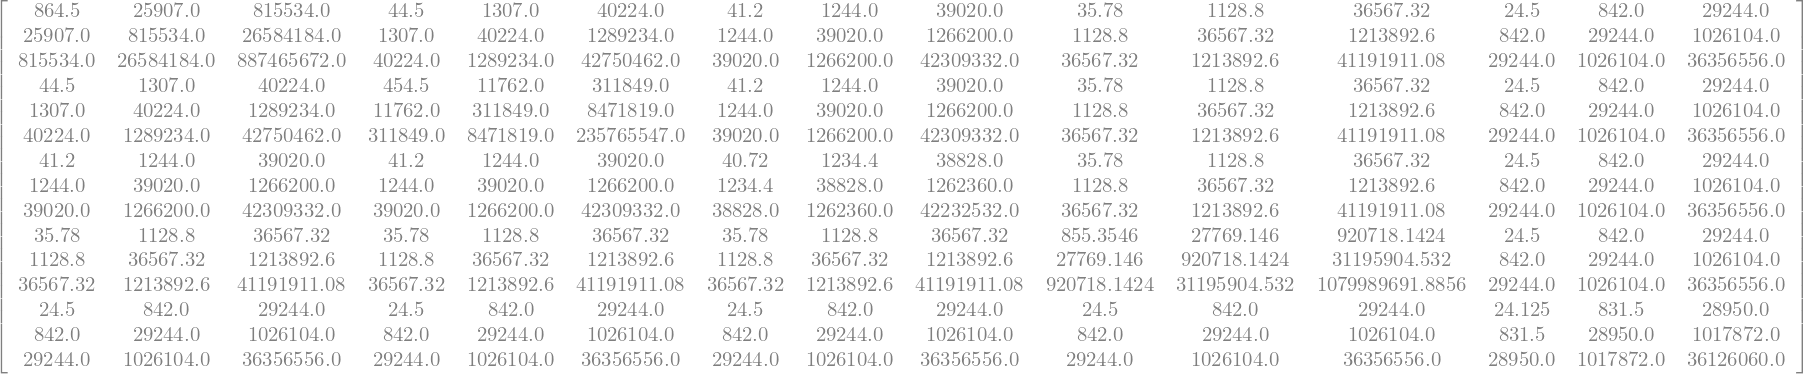

In [600]:
DiffA = np.zeros([(k+1)*n,(k+1)*n])
Diffb = np.zeros((k+1)*n)
# Fill in matrix with values for Aw=b  
for i in range(n):
    for j in range(k+1):
        # v = vertical index
        v = i*(k+1)+j
        dwij = Poly(Inac.diff(wMat[i,j]).doit())
        Diffb[v] = -1*dwij.coeffs()[-1]
        for i2 in range(n):
            for j2 in range(k+1):
                # h = horizontal index
                h = i2*(k+1)+j2
                #print(v, h)
                DiffA[v,h] = dwij.coeff_monomial(wMat[i2, j2])
                
    
# Then solve for w
DiffMatrixA = Matrix(DiffA)
DiffMatrixb = Matrix(Diffb)
DiffMatrixA

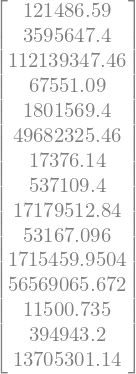

In [601]:
DiffMatrixb

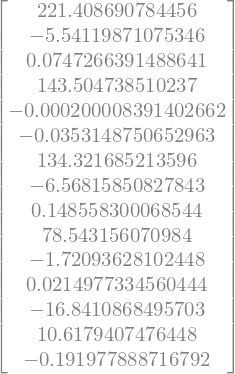

In [602]:
results = DiffMatrixA.inv()*DiffMatrixb
results

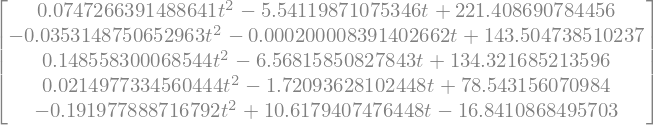

In [603]:
wExpr = results.reshape(n, k+1)*ts
wExpr

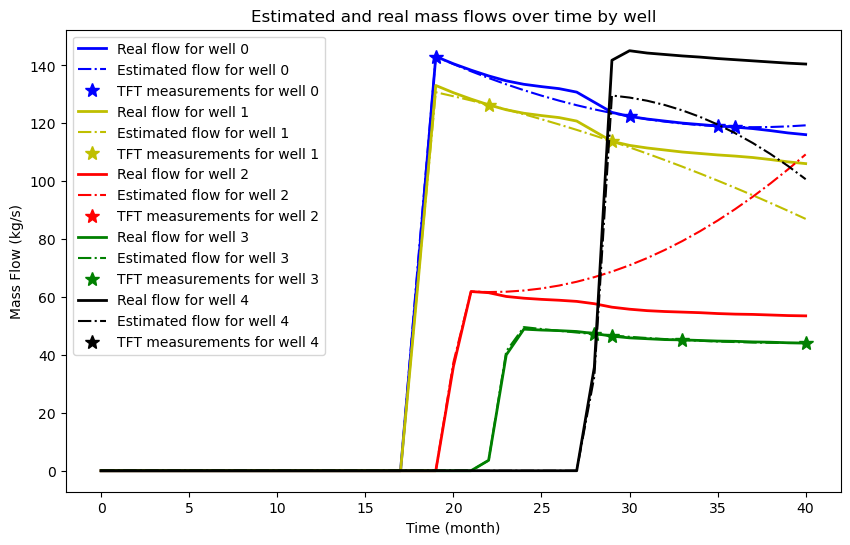

In [604]:
# Plot results from all wells
plt.figure(figsize=(10,6))
colours=['b', 'y', 'r', 'g', 'k']
for i in range(n):
    plt.plot(range(T),mReal[i,:][:], colours[i]+'-', lw=2, label="Real flow for well "+str(i))
    # Plot Time-Dependently
    toplot = []
    for time in range(T):
        resplot = wExpr[i].subs(t, time)
        toplot.append(resplot*zReal[i,time])
        #print(time, toplot)
    plt.plot(range(T),toplot, colours[i]+'-.', lw=1.5, label="Estimated flow for well "+str(i))
    # Plot TFT points
    monthplot = []
    tftplot = []
    for month,element in enumerate(dTrain[i,:]):
        if element==1:
            monthplot.append(month)
            tftplot.append(mReal[i,month])
    plt.plot(monthplot, tftplot, colours[i]+'*', markersize=10, label="TFT measurements for well "+str(i))
            
plt.title("Estimated and real mass flows over time by well")
plt.xlabel("Time (month)")
plt.ylabel("Mass Flow (kg/s)")
plt.legend()


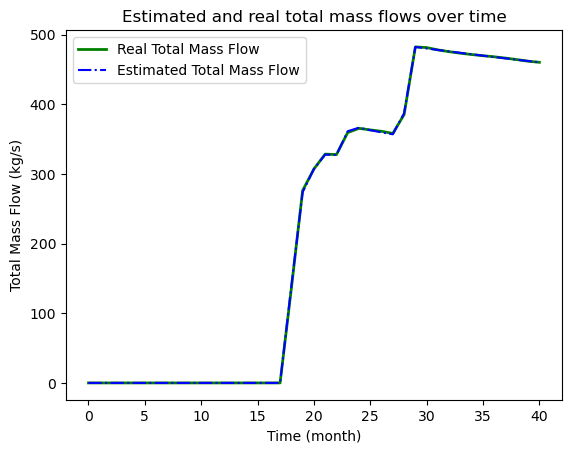

In [605]:
# Plot total flow vs found total flow
totalFlowFound = np.zeros((T,1))
times = range(T)
for time in range(T):
    tff = [wExpr[i].subs(t, time)*zReal[i,time] for i in range(n)]
    #print(t, tff)
    totalFlowFound[time] = sum(tff)

plt.plot(list(Matrix(times).T), list(MReal), 'g-', lw=2, label="Real Total Mass Flow")
plt.plot(times,totalFlowFound, 'b-.', lw=1.5, label="Estimated Total Mass Flow")

plt.title("Estimated and real total mass flows over time")
plt.xlabel("Time (month)")
plt.ylabel("Total Mass Flow (kg/s)")
plt.legend()

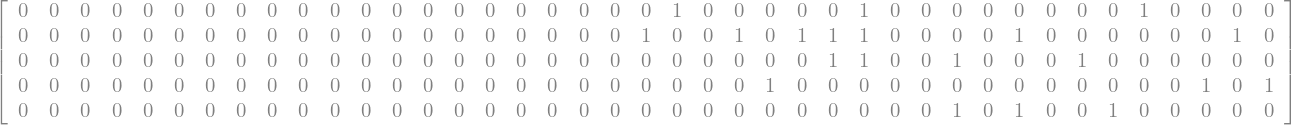

In [606]:
dTest = Matrix(zeros(n, T))
index = 0
for i2 in range(n):
    for j2 in range(T):
        if zReal[i2,j2]==1.0:
            if index not in sampleTrain:   #Ensure that our test points are not in training set
                #print(i2, j2, index)
                if index in sampleTest:
                    dTest[i2, j2] = 1
            index = index + 1
dTest

In [608]:
# Calculate average out of sample squared error (MSE). Then sqrt
OOSerror = 0
for i in range(n):
    for time in range(T):
        if dTest[i,time]:
            real = mReal[i, time]
            estimated = wExpr[i].subs(t, time)
            RSS = (real - estimated)**2
            OOSerror = OOSerror + RSS
                
aveOOSerror = OOSerror / pTest
RMSE = sqrt(aveOOSerror)
RMSE                    # Unit = same as unit of mass flow [kg/s]?

Bayesian model based on normal distribution of provided data. Bishop book